# Metrics for First N Samples

Re-compute evaluation metrics restricted to the **first N unique samples** (by `frame_index`)
from a benchmark run, without re-running the full benchmark.

**Why this is needed:** results are saved in two separate files — `evaluation_results.csv`
(correct predictions) and `evaluation_wrongs.csv` (wrong/error predictions) — with no
common "label" to slice by sample count. By sorting the union of `frame_index` values from
both files, we can reconstruct the original sample ordering and restrict analysis to the
first N.

In [30]:
from pathlib import Path
import re

# ── Configuration ─────────────────────────────────────────────────────────────
# Number of samples to consider (set to None to use all samples)
N = 250

# Parent folder containing timestamped result sub-folders (YYYYMMDD_HHMMSS).
# The sub-folder with the lexicographically largest name is chosen automatically.

action_names = ['change_atom_action', 'remove_atom_action', 'swap_atoms_action', 'add_atom_action', 'move_atom_action', 'move_towards_atom_action', 'insert_between_atoms_action', 'delete_below_atom_action', 'rotate_around_atom_action','super_cell_action']
model_names = ['gemini_2_5_pro', 'gemini_3_1_pro_preview', 'qwen3_32B', 'o3', 'o4_mini', 'deepseek_chat', 'llama3_70B', 'qwen3_14B', 'qwen3_8B', 'qwen3_4B']

model_name = model_names[0]
action_name = action_names[2]

DIR = Path(r"..\..\results\AtomWorld") / model_name / action_name

timestamped = [p for p in DIR.iterdir() if p.is_dir() and re.fullmatch(r"\d{8}_\d{6}", p.name)]
if not timestamped:
    raise FileNotFoundError(f"No timestamped result folders found in {DIR}")

RESULTS_DIR = max(timestamped, key=lambda p: p.name)
print(f"Using results folder: {RESULTS_DIR.name}")

# ─────────────────────────────────────────────────────────────────────────────

MAX_DIST_THRESHOLD = 0.3


Using results folder: 20260326_082745


In [25]:
import pandas as pd

# ── Load raw data robustly ─────────────────────────────────────────────────────
def _read_first_existing_csv(results_dir: Path, candidate_names: list[str], label: str):
    """Load the first existing CSV from candidate names; return (df_or_none, filename_or_none)."""
    for name in candidate_names:
        path = results_dir / name
        if path.exists():
            df = pd.read_csv(path)
            print(f"Loaded {label}: {path.name} ({len(df)} rows)")
            return df, path.name
    return None, None

result_candidates = [
    "evaluation_results.csv",
    f"{action_name}_evaluation_results_fixed.csv",
]
wrong_candidates = [
    "evaluation_wrongs.csv",
    f"{action_name}_evaluation_wrongs_fixed_relabeled.csv",
]

df_results, results_file = _read_first_existing_csv(RESULTS_DIR, result_candidates, "results")
df_wrongs, wrongs_file = _read_first_existing_csv(RESULTS_DIR, wrong_candidates, "wrongs")

if df_results is None and df_wrongs is None:
    raise FileNotFoundError(
        "No evaluation CSVs found. Tried: "
        f"results={result_candidates}, wrongs={wrong_candidates} in {RESULTS_DIR}"
    )

if df_results is None:
    print("Results CSV missing; treating this run as all wrong/error samples.")
    df_results = pd.DataFrame()

if df_wrongs is None:
    print("Wrongs CSV missing; treating this run as all-correct samples.")
    df_wrongs = pd.DataFrame()

# ── Determine the first N unique frame indices ────────────────────────────────
# Prefer frame_index-based slicing if available in at least one file.
results_has_frame = "frame_index" in df_results.columns
wrongs_has_frame = "frame_index" in df_wrongs.columns

if results_has_frame or wrongs_has_frame:
    # Build union from whichever side provides frame_index.
    result_frames = set(df_results["frame_index"]) if results_has_frame else set()
    wrong_frames = set(df_wrongs["frame_index"]) if wrongs_has_frame else set()
    all_frame_indices = sorted(result_frames.union(wrong_frames))
    total_available = len(all_frame_indices)

    if N is None or N >= total_available:
        selected_frames = set(all_frame_indices)
        n_used = total_available
        print(f"Using all {total_available} available samples (by frame_index).")
    else:
        selected_frames = set(all_frame_indices[:N])
        n_used = N
        print(f"Using first {N} of {total_available} available samples (by frame_index).")

    df_res_N = (
        df_results[df_results["frame_index"].isin(selected_frames)].copy()
        if results_has_frame else
        df_results.copy()
    )
    df_wrong_N = (
        df_wrongs[df_wrongs["frame_index"].isin(selected_frames)].copy()
        if wrongs_has_frame else
        df_wrongs.copy()
    )

else:
    # ── Fallback path: no frame_index in either file ──────────────────────────
    print("`frame_index` missing in both files; using row-order fallback.")

    df_results_tagged = df_results.copy()
    df_results_tagged["_source"] = "correct"

    df_wrongs_tagged = df_wrongs.copy()
    df_wrongs_tagged["_source"] = "wrong"

    df_all = pd.concat([df_results_tagged, df_wrongs_tagged], ignore_index=True)

    total_available = len(df_all)
    if N is None or N >= total_available:
        df_all_N = df_all
        n_used = total_available
        print(f"Using all {total_available} available rows (row-order fallback).")
    else:
        df_all_N = df_all.iloc[:N].copy()
        n_used = N
        print(f"Using first {N} of {total_available} available rows (row-order fallback).")

    df_res_N = df_all_N[df_all_N["_source"] == "correct"].drop(columns=["_source"], errors="ignore").copy()
    df_wrong_N = df_all_N[df_all_N["_source"] == "wrong"].drop(columns=["_source"], errors="ignore").copy()

print(f"  Correct results : {len(df_res_N)}")
print(f"  Wrong results   : {len(df_wrong_N)}")
print(f"  Sum check (== {n_used}): {len(df_res_N) + len(df_wrong_N)}")

Loaded results: evaluation_results.csv (93 rows)
Loaded wrongs: evaluation_wrongs.csv (157 rows)
Using all 250 available samples (by frame_index).
  Correct results : 93
  Wrong results   : 157
  Sum check (== 250): 250


In [10]:
import numpy as np

# ── Core metrics ──────────────────────────────────────────────────────────────
total       = len(df_res_N) + len(df_wrong_N)
n_correct   = len(df_res_N)
n_wrong     = len(df_wrong_N)
accuracy    = n_correct / total if total else float("nan")
error_rate  = n_wrong   / total if total else float("nan")

# RMSD and max_diff stats (only from correct predictions)
rmsd_stats     = df_res_N["rmsd"].describe()    if len(df_res_N) else pd.Series(dtype=float)
max_diff_stats = df_res_N["max_diff"].describe() if len(df_res_N) else pd.Series(dtype=float)

# Restricted accuracy (max_diff < threshold)
n_strict = len(df_res_N[df_res_N["max_diff"] <= MAX_DIST_THRESHOLD]) if len(df_res_N) else 0
strict_accuracy = n_strict / total if total else float("nan")

# Wrong-type breakdown
wrong_type_counts = (
    df_wrong_N["wrong_type"].value_counts()
    if "wrong_type" in df_wrong_N.columns and len(df_wrong_N)
    else pd.Series(dtype=int)
)

# ── Summary printout ──────────────────────────────────────────────────────────
sep = "─" * 50
print(sep)
print(f"  Samples analysed  : {total} (first {n_used} unique frame indices)")
print(sep)
print(f"  Correct           : {n_correct}  ({accuracy:.1%})")
print(f"  Wrong / error     : {n_wrong}   ({error_rate:.1%})")
print(f"  Strict accuracy   : {n_strict}  ({strict_accuracy:.1%})  [max_diff < {MAX_DIST_THRESHOLD}]")
print(sep)

if len(df_res_N):
    print("  RMSD (correct predictions):")
    print(f"    mean={rmsd_stats['mean']:.6f}  std={rmsd_stats['std']:.6f}"
          f"  min={rmsd_stats['min']:.6f}  max={rmsd_stats['max']:.6f}")
    print("  max_diff (correct predictions):")
    print(f"    mean={max_diff_stats['mean']:.6f}  std={max_diff_stats['std']:.6f}"
          f"  min={max_diff_stats['min']:.6f}  max={max_diff_stats['max']:.6f}")
    print(sep)

if len(wrong_type_counts):
    print("  Wrong-type breakdown:")
    for wtype, cnt in wrong_type_counts.items():
        print(f"    {wtype:<30} {cnt:>4}  ({cnt/total:.1%})")
    print(sep)

──────────────────────────────────────────────────
  Samples analysed  : 250 (first 250 unique frame indices)
──────────────────────────────────────────────────
  Correct           : 170  (68.0%)
  Wrong / error     : 80   (32.0%)
  Strict accuracy   : 158  (63.2%)  [max_diff < 0.3]
──────────────────────────────────────────────────
  RMSD (correct predictions):
    mean=0.010053  std=0.025752  min=0.000013  max=0.145053
  max_diff (correct predictions):
    mean=0.044422  std=0.110130  min=0.000050  max=0.490911
──────────────────────────────────────────────────
  Wrong-type breakdown:
    StructureMismatch                58  (23.2%)
    OutputFormatError                20  (8.0%)
    AtomCountMismatch                 1  (0.4%)
──────────────────────────────────────────────────


## Re-evaluate with different `stol` tolerances

Re-run `StructureMatcher` on **all parseable entries** (both correct and wrong) using a range
of `stol` values. A stricter (smaller) `stol` may reject previously-correct entries, while a
more lenient (larger) `stol` may rescue StructureMismatch entries.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.io.cif import CifParser
from src.utils.extract_data import extract_from_string
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
STOL_VALUES = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _parse_cif(cif_string):
    """Parse a CIF string into a pymatgen Structure (or None on failure)."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return CifParser.from_str(cif_string).parse_structures(primitive=False)[0]
    except Exception:
        return None

def _try_match(target_struct, gen_struct, stol):
    """Return (rmsd, max_dist) if StructureMatcher.fit succeeds, else None."""
    matcher = StructureMatcher(primitive_cell=False, stol=stol)
    if matcher.fit(target_struct, gen_struct):
        return matcher.get_rms_dist(target_struct, gen_struct)
    return None

# ── Build a unified list of (target_struct, gen_struct) for ALL parseable entries ──

parsed_all = []  # list of (target_struct, gen_struct, source)

# 1) From correct results: generated_cif is already clean CIF
for _, row in df_res_N.iterrows():
    target = _parse_cif(row["target_cif"])
    gen = _parse_cif(row["generated_cif"])
    parsed_all.append((target, gen, "correct"))

# 2) From wrong results: only StructureMismatch entries have valid structures
#    generated_output is raw LLM output — extract CIF from <cif>...</cif> tags
df_mismatch = df_wrong_N[df_wrong_N["wrong_type"] == "StructureMismatch"].copy()
for _, row in df_mismatch.iterrows():
    target = _parse_cif(row["target_cif"])
    raw_output = row["generated_output"]
    cif_str = extract_from_string(raw_output, format="cif")
    gen = _parse_cif(cif_str) if cif_str else None
    parsed_all.append((target, gen, "mismatch"))

# Count non-structural errors (cannot be rescued by changing stol)
n_other_errors = len(df_wrong_N[df_wrong_N["wrong_type"] != "StructureMismatch"])

print(f"Parseable pairs from correct results : {sum(1 for t, g, s in parsed_all if s == 'correct' and t and g)}")
print(f"Parseable pairs from StructureMismatch: {sum(1 for t, g, s in parsed_all if s == 'mismatch' and t and g)}")
print(f"Other errors (not re-evaluated)       : {n_other_errors}")

# ── Sweep stol values ────────────────────────────────────────────────────────
records = []

for stol in STOL_VALUES:
    n_matched = 0
    for target, gen, source in parsed_all:
        if target is None or gen is None:
            continue
        result = _try_match(target, gen, stol)
        if result is not None:
            n_matched += 1
    records.append({
        "stol": stol,
        "matched": n_matched,
        "unmatched_structural": len(parsed_all) - n_matched,
        "other_errors": n_other_errors,
        "total": total,
        "success_rate": n_matched / total if total else float("nan"),
    })

df_stol = pd.DataFrame(records)
print("\n" + df_stol.to_string(index=False))

Parseable pairs from correct results : 170
Parseable pairs from StructureMismatch: 58
Other errors (not re-evaluated)       : 22

 stol  matched  unmatched_structural  other_errors  total  success_rate
  0.1      146                    82            22    250         0.584
  0.2      154                    74            22    250         0.616
  0.3      158                    70            22    250         0.632
  0.5      170                    58            22    250         0.680
  0.7      184                    44            22    250         0.736
  1.0      198                    30            22    250         0.792
  1.5      224                     4            22    250         0.896
  2.0      224                     4            22    250         0.896


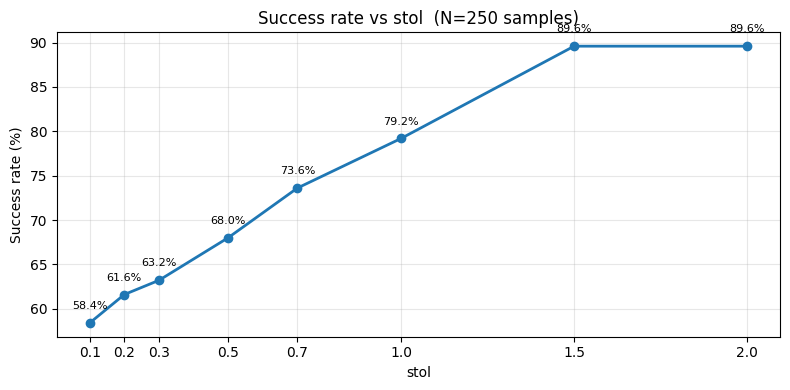

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_stol["stol"], df_stol["success_rate"] * 100, "o-", linewidth=2)
ax.set_xlabel("stol")
ax.set_ylabel("Success rate (%)")
ax.set_title(f"Success rate vs stol  (N={n_used} samples)")
ax.set_xticks(df_stol["stol"])
ax.grid(True, alpha=0.3)
for _, row in df_stol.iterrows():
    ax.annotate(f"{row['success_rate']:.1%}", (row["stol"], row["success_rate"] * 100),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

[info] Loaded results from evaluation_results.csv (225 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (25 rows)
[info] Loaded results from evaluation_results.csv (159 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (91 rows)
[info] Loaded results from evaluation_results.csv (239 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (11 rows)
[info] Loaded results from evaluation_results.csv (250 rows)
[info] Missing wrongs CSV in 20260326_222721; treating as all correct.
[info] Loaded results from evaluation_results.csv (248 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (2 rows)
[info] Loaded results from evaluation_results.csv (961 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (39 rows)
[info] Loaded results from evaluation_results.csv (207 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (43 rows)
[info] Loaded results from evaluation_results.csv (205 rows)
[info] Loaded wrongs from evaluation_wrongs.csv (45 rows)
[info] Loaded results from evaluatio

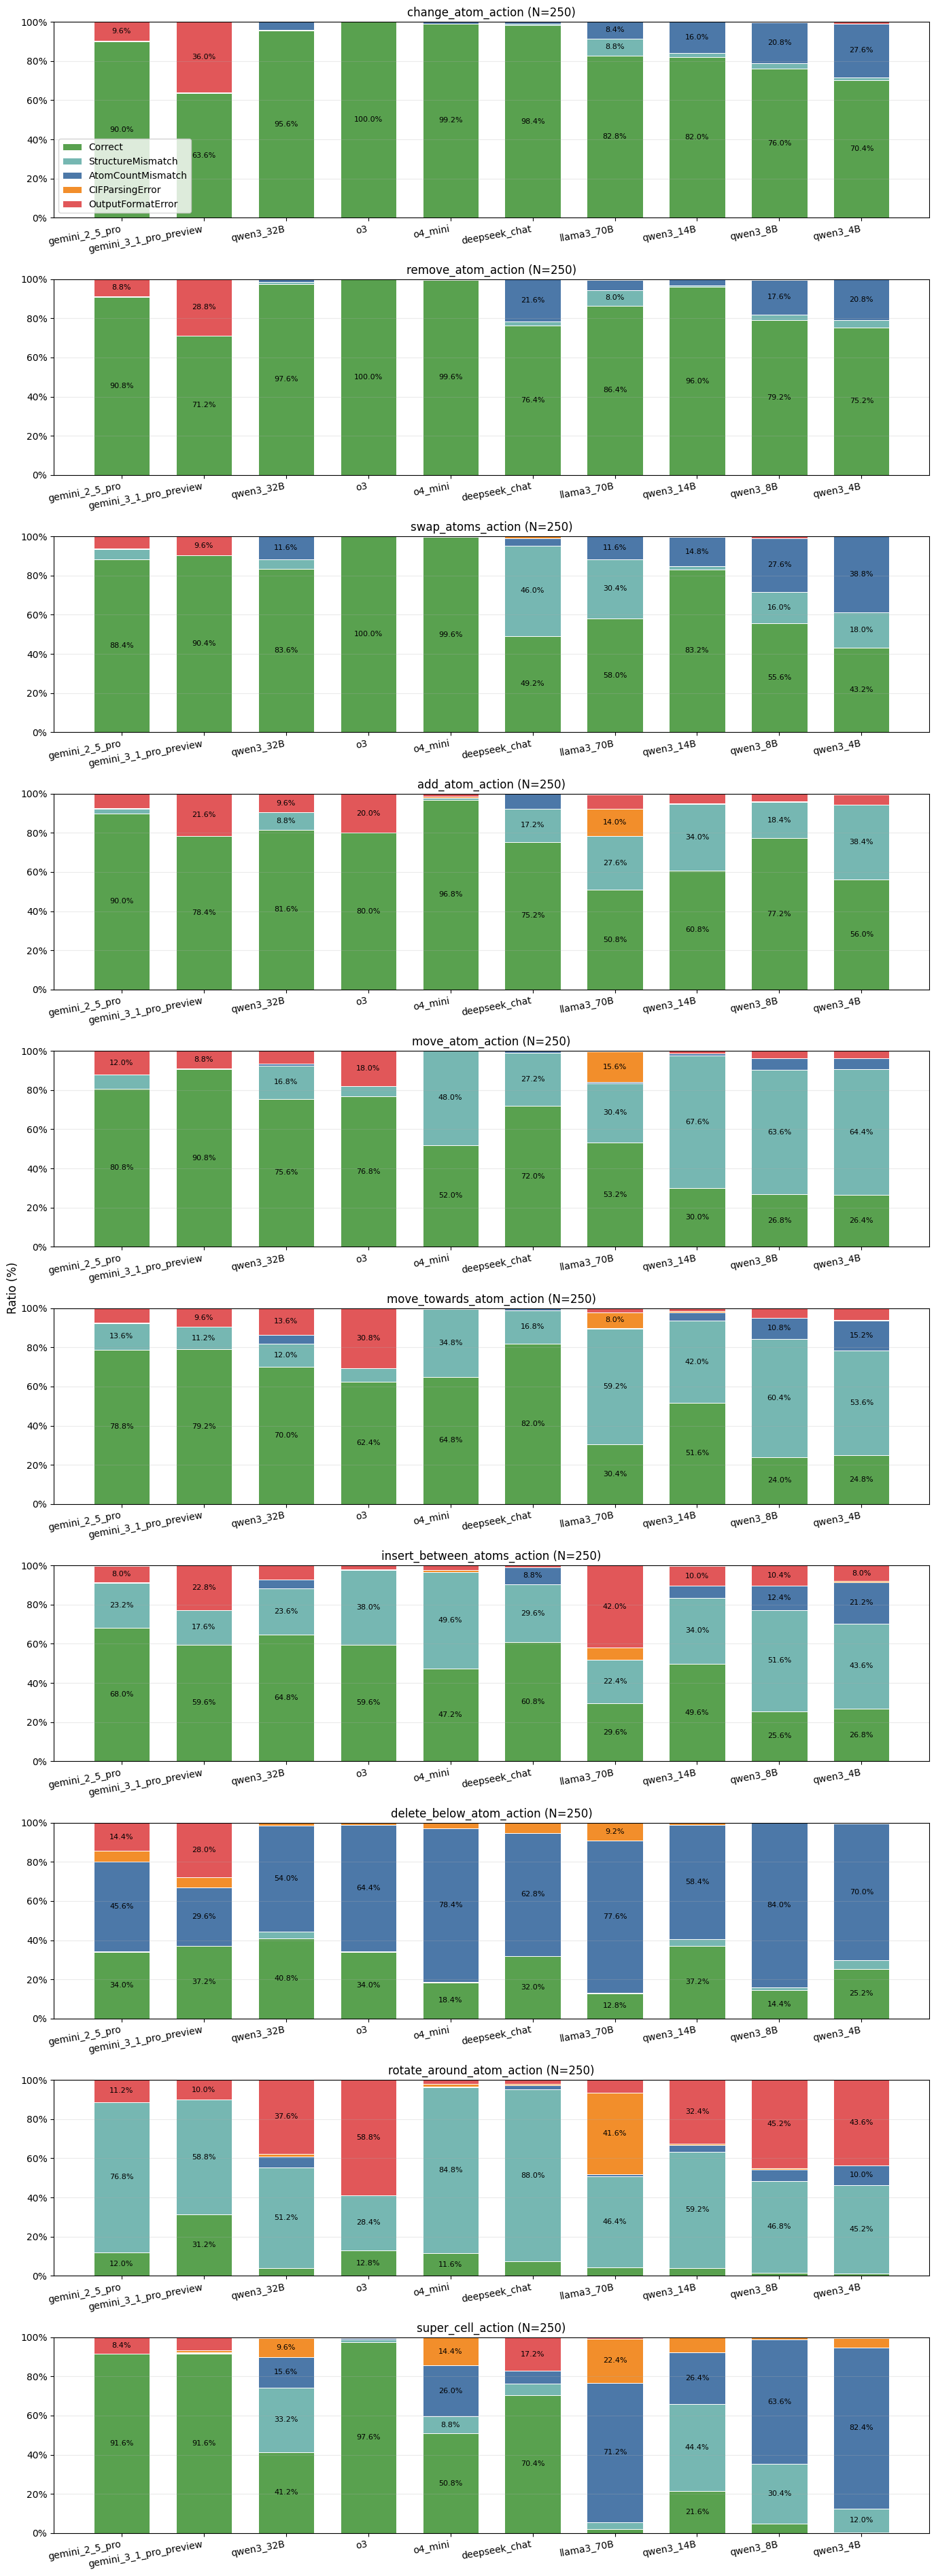

,action,model,Total,Correct,StructureMismatch,AtomCountMismatch,CIFParsingError,OutputFormatError
0,add_atom_action,deepseek_chat,250,75.2,17.2,7.6,0.0,0.0
1,add_atom_action,gemini_2_5_pro,250,90.0,2.4,0.4,0.0,7.2
2,add_atom_action,gemini_3_1_pro_preview,250,78.4,0.0,0.0,0.0,21.6
3,add_atom_action,llama3_70B,250,50.8,27.6,0.0,14.0,7.2
4,add_atom_action,o3,250,80.0,0.0,0.0,0.0,20.0
...,...,...,...,...,...,...,...,...
95,swap_atoms_action,o4_mini,250,99.6,0.4,0.0,0.0,0.0
96,swap_atoms_action,qwen3_14B,250,83.2,1.6,14.8,0.0,0.4
97,swap_atoms_action,qwen3_32B,250,83.6,4.8,11.6,0.0,0.0
98,swap_atoms_action,qwen3_4B,250,43.2,18.0,38.8,0.0,0.0


In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================== USER CONFIG ==============================
RESULTS_ROOT = Path(r"..\..\results\AtomWorld")

# You can change these lists later.
selected_actions = action_names
selected_models = model_names

# Number of samples to evaluate per model/action. Set to None to use all.
N = 250

# Fixed stack order requested: Correct + 4 wrong types.
wrong_types_order = [
    "StructureMismatch",
    "AtomCountMismatch",
    "CIFParsingError",
    "OutputFormatError",
]
n_wrong_types = 4
# =======================================================================


def _find_latest_results_dir(results_root: Path, model_name: str, action_name: str) -> Path:
    run_root = results_root / model_name / action_name
    if not run_root.exists():
        raise FileNotFoundError(f"Missing path: {run_root}")

    timestamped = [
        p for p in run_root.iterdir()
        if p.is_dir() and re.fullmatch(r"\d{8}_\d{6}", p.name)
    ]
    if not timestamped:
        raise FileNotFoundError(f"No timestamped folders found in: {run_root}")
    return max(timestamped, key=lambda p: p.name)


def _read_first_existing_csv(results_dir: Path, candidate_names: list[str]):
    """Load the first existing CSV from candidate names; return (df_or_none, path_or_none)."""
    for name in candidate_names:
        path = results_dir / name
        if path.exists():
            return pd.read_csv(path), path
    return None, None


def _load_first_n_split(results_dir: Path, action_name: str, n: int | None):
    result_candidates = [
        "evaluation_results.csv",
        f"{action_name}_evaluation_results_fixed.csv",
    ]
    wrong_candidates = [
        "evaluation_wrongs.csv",
        f"{action_name}_evaluation_wrongs_fixed_relabeled.csv",
    ]

    df_results, results_path = _read_first_existing_csv(results_dir, result_candidates)
    df_wrongs, wrongs_path = _read_first_existing_csv(results_dir, wrong_candidates)

    if df_results is None and df_wrongs is None:
        raise FileNotFoundError(
            f"No evaluation files found in {results_dir}. "
            f"Tried results={result_candidates}, wrongs={wrong_candidates}"
        )

    if df_results is None:
        print(f"[info] Missing results CSV in {results_dir.name}; treating as all wrong/error.")
        df_results = pd.DataFrame()
    else:
        print(f"[info] Loaded results from {results_path.name} ({len(df_results)} rows)")

    if df_wrongs is None:
        print(f"[info] Missing wrongs CSV in {results_dir.name}; treating as all correct.")
        df_wrongs = pd.DataFrame()
    else:
        print(f"[info] Loaded wrongs from {wrongs_path.name} ({len(df_wrongs)} rows)")

    results_has_frame = "frame_index" in df_results.columns
    wrongs_has_frame = "frame_index" in df_wrongs.columns

    if results_has_frame or wrongs_has_frame:
        all_frame_indices = sorted(
            (set(df_results["frame_index"]) if results_has_frame else set())
            .union(set(df_wrongs["frame_index"]) if wrongs_has_frame else set())
        )
        if n is None or n >= len(all_frame_indices):
            selected_frames = set(all_frame_indices)
        else:
            selected_frames = set(all_frame_indices[:n])

        df_res_n = (
            df_results[df_results["frame_index"].isin(selected_frames)].copy()
            if results_has_frame else
            df_results.copy()
        )
        df_wrong_n = (
            df_wrongs[df_wrongs["frame_index"].isin(selected_frames)].copy()
            if wrongs_has_frame else
            df_wrongs.copy()
        )
    else:
        df_results_tagged = df_results.copy()
        df_results_tagged["_source"] = "correct"

        df_wrongs_tagged = df_wrongs.copy()
        df_wrongs_tagged["_source"] = "wrong"

        df_all = pd.concat([df_results_tagged, df_wrongs_tagged], ignore_index=True)
        if n is None or n >= len(df_all):
            df_all_n = df_all
        else:
            df_all_n = df_all.iloc[:n].copy()

        df_res_n = (
            df_all_n[df_all_n["_source"] == "correct"]
            .drop(columns=["_source"], errors="ignore")
            .copy()
        )
        df_wrong_n = (
            df_all_n[df_all_n["_source"] == "wrong"]
            .drop(columns=["_source"], errors="ignore")
            .copy()
        )

    return df_res_n, df_wrong_n


records = []
wrong_type_global_counts = pd.Series(dtype=float)

for action_name in selected_actions:
    for model_name in selected_models:
        try:
            results_dir = _find_latest_results_dir(RESULTS_ROOT, model_name, action_name)
            df_res_n, df_wrong_n = _load_first_n_split(results_dir, action_name, N)
        except FileNotFoundError as e:
            print(f"[skip] {model_name} / {action_name}: {e}")
            continue

        total = len(df_res_n) + len(df_wrong_n)
        if total == 0:
            print(f"[skip] {model_name} / {action_name}: zero samples")
            continue

        wrong_counts = (
            df_wrong_n["wrong_type"].value_counts()
            if "wrong_type" in df_wrong_n.columns and len(df_wrong_n)
            else pd.Series(dtype=float)
        )
        wrong_type_global_counts = wrong_type_global_counts.add(wrong_counts, fill_value=0)

        row = {
            "action": action_name,
            "model": model_name,
            "Total": int(total),
            "Correct": int(len(df_res_n)),
        }
        for wtype, cnt in wrong_counts.items():
            row[wtype] = int(cnt)
        records.append(row)


df_counts = pd.DataFrame(records).fillna(0)
if df_counts.empty:
    raise ValueError("No data found for the selected actions/models.")

meta_cols = {"action", "model", "Total"}
all_outcome_cols = [c for c in df_counts.columns if c not in meta_cols]

if wrong_types_order is None:
    selected_wrong_types = wrong_type_global_counts.sort_values(ascending=False).index.tolist()[:n_wrong_types]
else:
    selected_wrong_types = wrong_types_order[:n_wrong_types]

# Backfill if fewer than n_wrong_types are available.
if len(selected_wrong_types) < n_wrong_types:
    remaining = [
        c for c in all_outcome_cols
        if c != "Correct" and c not in selected_wrong_types
    ]
    selected_wrong_types += remaining[: n_wrong_types - len(selected_wrong_types)]

stack_cols = ["Correct"] + selected_wrong_types
for col in stack_cols:
    if col not in df_counts.columns:
        df_counts[col] = 0

# Aggregate non-selected wrong types into "OtherWrong" so bars still sum to 100%.
excluded_wrong_cols = [
    c for c in all_outcome_cols
    if c not in stack_cols
]
if excluded_wrong_cols:
    df_counts["OtherWrong"] = df_counts[excluded_wrong_cols].sum(axis=1)
    stack_cols.append("OtherWrong")

# Convert to percentages.
df_ratio = df_counts.copy()
for col in stack_cols:
    df_ratio[col] = (df_ratio[col] / df_ratio["Total"]) * 100

present_actions = [a for a in selected_actions if a in set(df_ratio["action"])]
if not present_actions:
    raise ValueError("No selected action has valid data.")

n_actions = len(present_actions)
fig, axes = plt.subplots(
    n_actions,
    1,
    figsize=(max(7, 1.0 * len(selected_models) + 3), 3.8 * n_actions),
    sharey=True,
 )
if n_actions == 1:
    axes = [axes]

palette = ["#59A14F", "#76B7B2", "#4C78A8", "#F28E2B", "#E15759"]
colors = {col: palette[i % len(palette)] for i, col in enumerate(stack_cols)}

for ax, action_name in zip(axes, present_actions):
    action_df = (
        df_ratio[df_ratio["action"] == action_name]
        .set_index("model")
        .reindex(selected_models)
        .fillna(0)
    )

    x = np.arange(len(selected_models))
    bottom = np.zeros(len(selected_models), dtype=float)

    for col in stack_cols:
        vals = action_df[col].to_numpy()
        bars = ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.68,
            color=colors[col],
            edgecolor="white",
            linewidth=0.7,
            label=col,
        )

        # Label larger segments for readability.
        for rect, v, b in zip(bars, vals, bottom):
            if v >= 8:
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    b + v / 2,
                    f"{v:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                )
        bottom += vals

    ax.set_title(f"{action_name} (N={N if N is not None else 'all'})")
    ax.set_xticks(x)
    ax.set_xticklabels(selected_models, rotation=10, ha="right")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.grid(axis="y", alpha=0.25)

axes[0].legend()
fig.supylabel("Ratio (%)")
plt.tight_layout()
plt.show()

# Optional table for inspection.
display(
    df_ratio[["action", "model", "Total"] + stack_cols]
    .sort_values(["action", "model"])
    .reset_index(drop=True)
)